## Week 1 Integrated Mini-Notebook

everything here is for the Mini-Project hands-on task: a full load -> process -> visualize pipeline using NumPy, Pandas, and Matplotlib together on the Titanic dataset.

## Step 1 - Load and Clean (Pandas)

Load the dataset and handle missing values, carrying forward the same cleaning approach from Day 4.

In [2]:
import pandas as pd

titanic = df = pd.read_csv("../titanic.csv")
print("Missing values before cleaning:")
print(titanic.isnull().sum())

# age: fill with median (robust to skew)
titanic["age"] = titanic["age"].fillna(titanic["age"].median())

# embarked / embark_town: fill with the most frequent value
titanic["embarked"] = titanic["embarked"].fillna(titanic["embarked"].mode()[0])
titanic["embark_town"] = titanic["embark_town"].fillna(titanic["embark_town"].mode()[0])

# deck: too many missing values to impute reliably
titanic = titanic.drop(columns=["deck"])
titanic = titanic.drop_duplicates()

print("\nMissing values after cleaning:")
print(titanic.isnull().sum())
print("\nShape:", titanic.shape)

Missing values before cleaning:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Shape: (775, 14)


## Step 2 - Derived Feature (NumPy)

Use NumPy to compute a derived numeric feature: a family size, and a z-score for fare that flags how unusual each passenger's fare was.

In [4]:
import numpy as np

# family size = siblings/spouses + parents/children + self
titanic["family_size"] = titanic["sibsp"] + titanic["parch"] + 1

# z-score for fare using NumPy, to flag unusually high/low fares
fare = titanic["fare"].to_numpy()
titanic["fare_zscore"] = (fare - np.mean(fare)) / np.std(fare)

print("Average family size:", round(np.mean(titanic["family_size"]), 2))
print("Largest family size:", np.max(titanic["family_size"]))
print("Number of passengers with an unusually high fare (z > 3):",
      int(np.sum(titanic["fare_zscore"] > 3)))

titanic[["fare", "fare_zscore", "family_size"]].head()

Average family size: 1.95
Largest family size: 11
Number of passengers with an unusually high fare (z > 3): 20


,fare,fare_zscore,family_size
0,7.2500,-0.527515,2
1,71.2833,0.695086,2
2,7.9250,-0.514627,1
3,53.1000,0.347909,2
4,8.0500,-0.512240,1


## Step 3 - Visualize (Matplotlib)

At least three labeled plots exploring the cleaned data, including a histogram and a scatter plot.

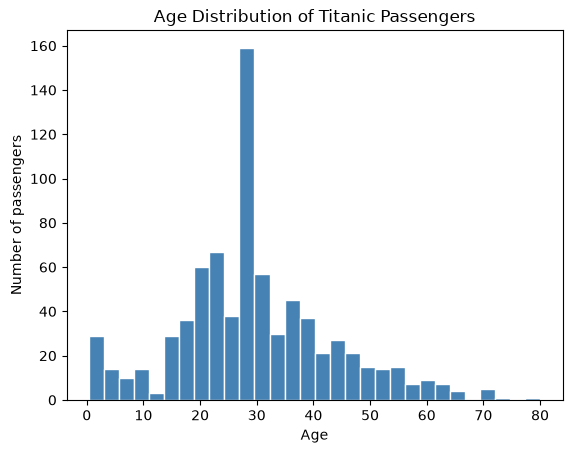

In [6]:
import matplotlib.pyplot as plt

# Plot 1: Histogram of age distribution
plt.hist(titanic["age"], bins=30, color="steelblue", edgecolor="white")
plt.xlabel("Age")
plt.ylabel("Number of passengers")
plt.title("Age Distribution of Titanic Passengers")
plt.show()

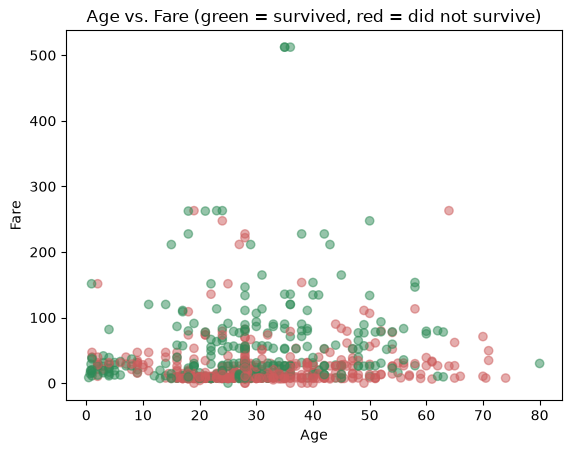

In [7]:
# Plot 2: Scatter plot of age vs. fare, colored by survival
colors = titanic["survived"].map({0: "indianred", 1: "seagreen"})

plt.scatter(titanic["age"], titanic["fare"], c=colors, alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs. Fare (green = survived, red = did not survive)")
plt.show()

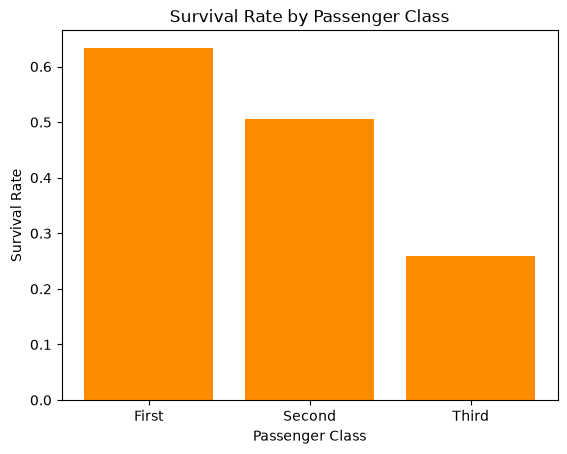

In [8]:
# Plot 3: Bar plot of survival rate by passenger class
survival_by_class = titanic.groupby("class")["survived"].mean()

plt.bar(survival_by_class.index, survival_by_class.values, color="darkorange")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Passenger Class")
plt.show()

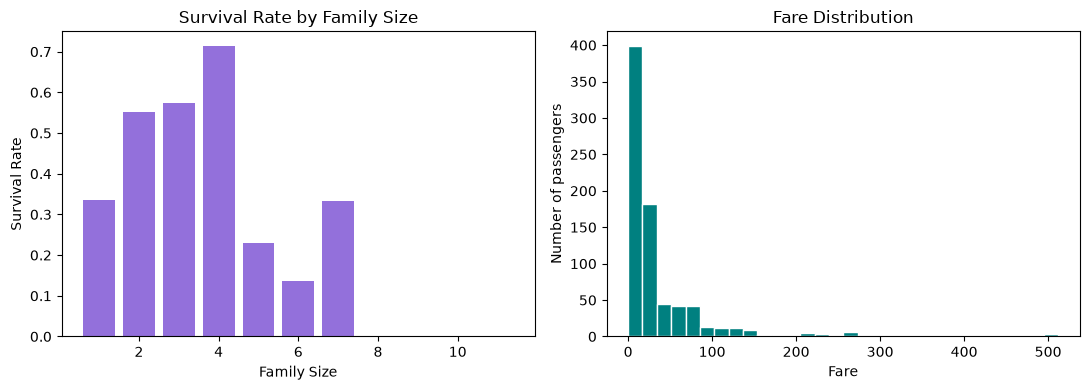

In [9]:
# Plot 4 (bonus): Subplots comparing family size vs. survival, and fare distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

survival_by_family = titanic.groupby("family_size")["survived"].mean()
axes[0].bar(survival_by_family.index, survival_by_family.values, color="mediumpurple")
axes[0].set_xlabel("Family Size")
axes[0].set_ylabel("Survival Rate")
axes[0].set_title("Survival Rate by Family Size")

axes[1].hist(titanic["fare"], bins=30, color="teal", edgecolor="white")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Number of passengers")
axes[1].set_title("Fare Distribution")

plt.tight_layout()
plt.show()

## Step 4 - Interpretation

**Age distribution:** Most passengers were young adults in their 20s-30s, with a smaller number of children and very few elderly passengers, giving the distribution a right skew.

**Age vs. Fare (by survival):** Survivors (green) are noticeably concentrated at higher fares, especially at younger ages, while low-fare passengers of all ages skew red (did not survive) - fare, as a proxy for class, was strongly tied to survival odds.

**Survival rate by class:** Survival rate drops sharply from 1st to 3rd class, confirming what the Day 4 groupby analysis showed at the individual class/sex level - passenger class was one of the strongest predictors of survival on the Titanic.

**Survival rate by family size (bonus):** Passengers traveling entirely alone (family size = 1) and those in very large families had lower survival rates than passengers in small families (2-4 members) - suggesting there was a "sweet spot" where having some family aboard helped coordination without becoming a liability when boarding lifeboats.

### Dataset source

`titanic.csv` - Titanic passenger data, the same dataset used in the Day 4 Pandas notebook (also a classic Kaggle dataset: https://www.kaggle.com/competitions/titanic). Keep this CSV in the same folder as this notebook (`notebooks/titanic.csv`).